# File organization

**Recipe 09** · Level 1 (Beginner) · Decision type: `Choice`

Recommend a destination folder from a fixed catalog using a file's name and text excerpt so Python can preview the proposed organization.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)

## What you will build

A small file-organization assistant for a shared office drive. Jev reads one file's name and a short excerpt of its text and picks exactly one of five options: the four real destination folders (`invoices`, `contracts`, `reports`, `correspondence`) or `unsorted`, Jev's own fallback for a file that matches none of them. Python never moves, creates, or reads a real file: it only renders a dry-run preview table of proposed destinations, and decides whether an answer is confident enough to place on its own or should stay in the `unsorted` row of that preview instead. By the end you will have looked at individual typed answers across the full range of confidence, seen the rule that acts on them, and run an evaluation that chooses its one setting on `validation` and reports on `test`.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_outcomes,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# file that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "destination"
        ]
    return answered[example.id]


run_header(
    9,
    "File organization",
    backend=backend,
    n_examples=len(scored),
)

Recipe 09: File organization
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `file_id`, the file's `filename`, and a short text `excerpt`. `build_state` passes on the filename and excerpt only; the identifier stays in Python and is attached to the proposal at the end, so it never passes through the model and every preview row still traces back to its file.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-mixed"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "file_id": "F3001",
  "filename": "Renewal_Quote_and_Terms.pdf",
  "excerpt": "This quote reflects the renewed service terms. Please sign and return to confirm acceptance of the twelve-month extension at the adjusted rate."
}
Jev sees:
{
  "filename": "Renewal_Quote_and_Terms.pdf",
  "excerpt": "This quote reflects the renewed service terms. Please sign and return to confirm acceptance of the twelve-month extension at the adjusted rate."
}


## The questions

There is one question, and it asks one thing: which folder should this file be organized into? A `Choice` fits because the five outcomes are exclusive and Jev should commit to exactly one. Four of the five options are the office's fixed destination folders; the fifth, `unsorted`, is the fallback this use case names, for a file whose name and excerpt do not clearly belong to any of the other four. `unsorted` is not "pick whichever folder seems closest"; it exists so that a file with no real match is named as such instead of being forced into a folder it does not belong in. Two folders are easy to confuse by surface wording alone (an invoice that mentions an existing agreement, or a renewal agreement that states a price), so `invoices`' and `contracts`' descriptions each say what the other folder covers instead, the same way the destination catalog is built: by Python, from a fixed list, never invented by the model.

In [3]:
questions = helpers.build_questions()
destination = questions["destination"]
print(destination.instructions)
for name, description in destination.criteria.items():
    print(f"  {name:15s} {description}")

Which folder should this file be organized into, based on its name and the excerpt of its text?
  invoices        Billing paperwork: invoices, receipts, purchase orders and payment confirmations. A document that is mostly an amount due, a payment term or a receipt number is an invoice even if it also references an existing contract; it is a contract only when its main content is the agreement itself, such as new or changed terms to sign.
  contracts       Legal agreements: signed contracts, non-disclosure agreements, vendor terms and lease or service renewals. A renewal notice that states a price is still a contract when what it asks for is a signature accepting new terms, not payment of a bill.
  reports         Internal reporting: status updates, sales or analytics summaries, and performance or project reviews written for people inside the company, not sent to a specific person.
  correspondence  Letters and message threads written to or from a specific person: emails, meeting notes 

## One answer up close

Before any aggregate number, look at three typed answers across the range this recipe covers: a file whose name and content point to two folders at once, a file with almost no text to go on, and a file whose name is actively misleading about what it contains. Each answer holds the chosen option, a probability for every option, the `confidence` explained above (the top probability rescaled so a uniform spread over five options reads as 0, `(p_max - 1/5) / (1 - 1/5)`), and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

Choice: contracts (confidence 0.34)
  contracts       0.47  #########
  invoices        0.28  ######
  reports         0.09  ##
  correspondence  0.08  ##
  unsorted        0.08  ##
Provenance: synthetic


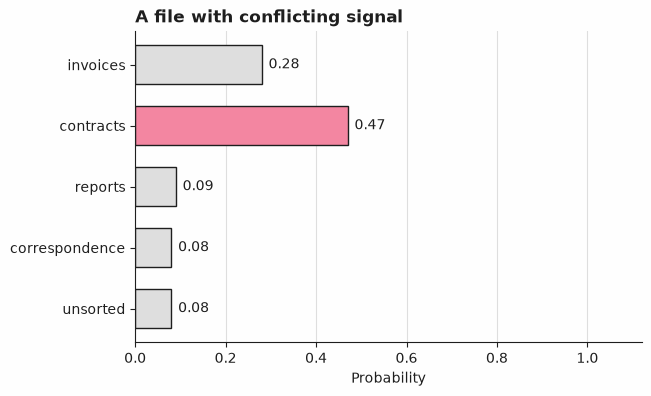

In [4]:
mixed_example = demo["d01-mixed"]
mixed_answer = decide(mixed_example)
show_answer(mixed_answer)
plot_answer_probabilities(mixed_answer, title="A file with conflicting signal")

"Renewal_Quote_and_Terms.pdf" carries both a quote (a price) and a request to sign and confirm an extension. The stored answer puts `contracts` on top at 0.47, so `confidence` is only 0.3375: `(0.47 - 0.2) / 0.8`. Confidence depends only on that top probability, not on how the rest is spread; here the remaining 0.53 happens to lean partly toward `invoices`, but it could just as well have piled onto `unsorted` and the formula would report the same 0.3375 either way. A low-confidence answer like this one says the top option did not clear much more than an even share, not that the file is unreadable.

In [5]:
short_example = demo["d02-short"]
short_answer = decide(short_example)
show_answer(short_answer)

Choice: invoices (confidence 0.01)
  invoices        0.21  ####
  contracts       0.20  ####
  correspondence  0.20  ####
  unsorted        0.20  ####
  reports         0.19  ####
Provenance: synthetic


"Noted, thanks." carries almost no signal either way, and the probabilities show it: the top option, `invoices`, barely leads the rest, which are themselves within a point of each other. A file this short is a hard case on purpose; there is often not enough text for any classifier, human or model, to place it with confidence.

In [6]:
lookalike_example = next(e for e in examples if e.id == "v11-lookalike")
lookalike_answer = decide(lookalike_example)
print(lookalike_example.fields["filename"])
print(lookalike_example.fields["excerpt"])
show_answer(lookalike_answer)

Status_Report_Vendor.pdf
Hi Alex, sorry for the delay in replying. I wanted to let you know we approved the budget increase for next quarter and will send the paperwork separately.
Choice: correspondence (confidence 0.50)
  correspondence  0.60  ############
  reports         0.18  ####
  invoices        0.08  ##
  unsorted        0.08  ##
  contracts       0.06  #
Provenance: synthetic


"Status_Report_Vendor.pdf" sounds like it belongs in `reports`, but the excerpt is an email reply to a specific person about a budget decision: whoever saved the file gave it a generic, misleading name. The stored answer calls it `correspondence`, which is this recipe's **gold label**: the correct folder recorded for evaluation ahead of time, from each option's description, not chosen by the model. `reports` only gets 0.18. The evaluation below counts this one as right, on purpose: a fixture set that only ever tested the filename, never the excerpt, would not teach anything about where a `Choice` answer has to look past a surface label. Nothing here says a real model would always read past a misleading filename, because nothing here is a real model: the probabilities were written by hand for this fixture, not produced by Jev.

## Python's part

Jev supplies the judgment; what happens with it is code. `propose_destination` in `helpers.py` places the chosen folder as is when Jev did not itself answer `unsorted` and the answer's confidence is at or above a threshold; both conditions send a file to the `unsorted` row of the preview otherwise, whatever the folder. `tests/test_helpers.py` checks the rule at the boundary, outside `0` to `1`, for an `unsorted` answer at high confidence, and for a low-confidence answer of every one of the four real folders, so a rule that quietly exempted one folder from the threshold would fail it.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook. `select_confidence_threshold` only sees one confidence number per example, which fits a rule with a single cutoff but not this one's two-part rule: an `unsorted` answer is never placed, however confident Jev is that nothing else fits, so it has no real confidence a selector could use. `helpers.selection_signal` keeps the search from ever being offered one: it chooses the threshold from only the answers that name a real folder, so an `unsorted` answer is already never placed at any threshold, leaving it out changes no accuracy or coverage number a real threshold could produce, only which numbers the search is allowed to propose. `select_confidence_threshold` picks the lowest threshold whose placed subset is perfectly accurate on `validation`, which is as much coverage as this fixture set allows without placing a wrong answer *on validation*. Applying that frozen threshold to the three answers shown above, plus one clearly confident file for contrast, shows both outcomes the rule can produce.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct, val_confidence = helpers.selection_signal(val_answers, val_gold)
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}")

confident_example = next(e for e in val_examples if e.id == "v01-invoice")
confident_answer = decide(confident_example)
for shown_example, shown_answer in (
    (mixed_example, mixed_answer),
    (short_example, short_answer),
    (lookalike_example, lookalike_answer),
    (confident_example, confident_answer),
):
    result = helpers.propose_destination(shown_example.fields["file_id"], shown_answer, threshold)
    print(
        f"{result.file_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {result.outcome} ({result.reason})"
    )

chosen threshold, frozen from here on: 0.5000 (a selection step, not a reported result)
F3001: contracts at confidence 0.34 -> review (confidence below the threshold)
F3002: invoices at confidence 0.01 -> review (confidence below the threshold)
F1011: correspondence at confidence 0.50 -> placed (confident match)
F1001: invoices at confidence 0.82 -> placed (confident match)


## Evaluation

The threshold was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.propose_destination` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside the counts, it renders the dry-run preview this use case calls for: every file next to the folder `propose_destination` proposes for it, with the files left `unsorted` grouped at the end, each with why, so the reader can see the organization that would be applied without anything being applied. `jev_cookbook.evaluation` then reports `accuracy` -- the fraction of all scored files whose raw choice equals the gold folder -- a confusion matrix across all five options, per-option precision and recall, and the coverage, accuracy and risk the frozen threshold produces on `test` (a narrower `accuracy`, over only the files the rule places, explained below). In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [8]:
def report(chosen, decided, gold, threshold):
    """Apply propose_destination to every answer and tally what it actually did."""
    results = [
        helpers.propose_destination(e.fields["file_id"], a, threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    placed = [
        (a, g)
        for r, a, g in zip(results, decided, gold, strict=True)
        if r.outcome == helpers.PLACED
    ]
    right = sum(a.choice == g for a, g in placed)
    reasons = {}
    for r in results:
        if r.outcome == helpers.REVIEW:
            reasons[r.reason] = reasons.get(r.reason, 0) + 1
    return results, len(placed), right, reasons


def render_preview(chosen, results, label):
    """The dry-run preview: every file next to its proposed destination, grouped by
    folder, with an `unsorted` row carrying why. This only prints; nothing here moves,
    creates, or reads a file."""
    by_destination = {folder: [] for folder in helpers.FOLDERS}
    by_destination[helpers.UNSORTED] = []
    for e, r in zip(chosen, results, strict=True):
        filename = e.fields["filename"]
        if r.outcome == helpers.PLACED:
            by_destination[r.destination].append(filename)
        else:
            by_destination[helpers.UNSORTED].append(f"{filename}  ({r.reason})")
    print(f"dry-run preview{label}")
    for folder in (*helpers.FOLDERS, helpers.UNSORTED):
        print(f"  {folder}/")
        for row in by_destination[folder]:
            print(f"    {row}")


val_results, n_placed, n_right, val_reasons = report(val_examples, val_answers, val_gold, threshold)
print(f"validation, {len(val_examples)} examples{selection}")
print(f"accuracy of the choice: {accuracy(val_gold, val_answers):.4f}{selection}{check}")
print(f"placed by the rule at this threshold: {n_placed} of {len(val_examples)}{selection}")
print(f"right among those placed: {n_right} of {n_placed}{selection}")
print(f"left unsorted: {val_reasons}{selection}")
render_preview(val_examples, val_results, selection)

validation, 19 examples (a selection step, not a reported result)
accuracy of the choice: 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
placed by the rule at this threshold: 10 of 19 (a selection step, not a reported result)
right among those placed: 10 of 10 (a selection step, not a reported result)
left unsorted: {'no folder matches': 3, 'confidence below the threshold': 6} (a selection step, not a reported result)
dry-run preview (a selection step, not a reported result)
  invoices/
    INV-10234_Acme_Supplies.pdf
    January_Utility_Statement.pdf
  contracts/
    Vendor_Services_Agreement_v3.docx
    NDA_Contractor_Reyes.pdf
  reports/
    Q3_Sales_Summary.xlsx
    Weekly_Status_Update_Oct06.docx
    Annual_Performance_Review_Dept.pdf
  correspondence/
    Letter_to_Client_Reply.docx
    Meeting_Notes_Oct03.txt
    Status_Report_Vendor.pdf
  unsorted/
    banana_bread_recipe.txt  (no folder matches)
    Renewal_Invoice_and_Agreement.pdf  (con

In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_results, n_placed_t, n_right_t, test_reasons = report(
    test_examples, test_answers, test_gold, threshold
)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(f"accuracy of the choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(f"placed by the rule: {n_placed_t} of {len(test_examples)}{check}")
print(f"right among those placed: {n_right_t} of {n_placed_t}{check}")
print(f"left unsorted: {test_reasons}{check}")
render_preview(test_examples, test_results, check)

test, 19 examples, threshold 0.5000 frozen (a pipeline check, not a Jev result)
accuracy of the choice: 0.9474 (a pipeline check, not a Jev result)
placed by the rule: 11 of 19 (a pipeline check, not a Jev result)
right among those placed: 10 of 11 (a pipeline check, not a Jev result)
left unsorted: {'no folder matches': 2, 'confidence below the threshold': 6} (a pipeline check, not a Jev result)
dry-run preview (a pipeline check, not a Jev result)
  invoices/
    INV-20144_Acme_Supplies.pdf
    February_Utility_Statement.pdf
    Lease_Renewal_Final_Terms.pdf
    INV-20199_Acme_Supplies.pdf
  contracts/
    Vendor_Services_Agreement_v4.docx
    NDA_Contractor_Price.pdf
  reports/
    Q4_Sales_Summary.xlsx
    Weekly_Status_Update_Nov03.docx
  correspondence/
    Letter_to_Client_Followup.docx
    Meeting_Notes_Nov05.txt
    Status_Report_Vendor_2.pdf
  unsorted/
    office_potluck_signup.docx  (no folder matches)
    Renewal_Invoice_and_Agreement_2.pdf  (confidence below the threshold)

In [ ]:
matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OPTIONS))
width = max(len(label) for label in matrix.labels)
# The header's leader ("predicted ->") and each row's leader ("gold <label>") are
# different fixed phrases; padding both to the same leader_width, derived from this
# same width, is what keeps the header's columns and every row's columns lined up,
# whatever width this recipe's own labels turn out to need.
leader_width = max(width + len("gold "), len("predicted ->"))
header = "  ".join(f"{label:>{width}s}" for label in matrix.labels)
print(f"Test confusion matrix, gold rows by predicted columns{check}:")
print(f"  {'predicted ->':<{leader_width}s}  {header}{check}")
for gold_label, row in zip(matrix.labels, matrix.matrix.tolist(), strict=True):
    counts = "  ".join(f"{count:{width}d}" for count in row)
    leader = f"gold {gold_label:<{width}s}"
    print(f"  {leader:<{leader_width}s}  {counts}{check}")
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

The one error on `test`, "Lease_Renewal_Final_Terms.pdf", lands in the `invoices` column though its gold folder is `contracts`: the document finalizes a lease renewal (a signed agreement), but it also restates an outstanding dollar balance for reference, and the stored answer leans on that surface cue at confidence 0.75, well above the frozen threshold. That pattern cannot be read as a finding about Jev: the probability was written by hand for this fixture set, which was built to include exactly one case like it. It is worth naming anyway, because it is the shape of mistake a confidence threshold alone cannot catch: a wrong answer the rule is sure of is placed, not sent to `unsorted`, which is why the risk number below is not zero.

For each folder, `precision` is the fraction of the rule's calls of that folder that were actually right, and `recall` is the fraction of that folder's real `test` files the rule found at all; `f1` is their harmonic mean, a single number that is low whenever either one is, and `support` is how many `test` files actually carry that gold label, so a recall figure is only as meaningful as its support is large.

In [11]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OPTIONS))
for label, counts in per_class.items():
    print(
        f"{label:15s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

invoices        precision 0.800  recall 1.000  f1 0.889  support 4 (a pipeline check, not a Jev result)
contracts       precision 1.000  recall 0.800  f1 0.889  support 5 (a pipeline check, not a Jev result)
reports         precision 1.000  recall 1.000  f1 1.000  support 4 (a pipeline check, not a Jev result)
correspondence  precision 1.000  recall 1.000  f1 1.000  support 4 (a pipeline check, not a Jev result)
unsorted        precision 1.000  recall 1.000  f1 1.000  support 2 (a pipeline check, not a Jev result)


`invoices` has the lowest precision of the four real folders on `test` (four of its five calls are right; the fifth is the lease renewal above, whose gold folder is `contracts`), while its recall is perfect: every file whose gold folder is `invoices` is still called `invoices`. `contracts` pays for the same file from the other side: its precision is perfect (every file the raw choice calls `contracts` really is `contracts`), but its recall drops to 0.8, because the lease renewal is the one `contracts` file the raw choice misses, calling it `invoices` instead. `unsorted` has perfect precision and perfect recall here, but for two different reasons: "office_potluck_signup.docx" is named `unsorted` confidently (0.85), while "scan0027.pdf" -- whose one-word excerpt, "Thanks.", carries almost no signal -- is named `unsorted` by the thinnest possible margin (confidence 0.025, the near-uniform five-way split breaking just barely toward `unsorted` rather than toward one of the four real folders). Both still count as right, because the raw choice only has to match the gold folder, not clear any confidence bar.

The `placed`/`unsorted` counts above come straight from `propose_destination` (`test_results`, built in the Evaluation section above); `evaluate_outcomes` reports the same split through `jev_cookbook.evaluation`'s own vocabulary, fed those outcomes directly (`accepted = [r.outcome == helpers.PLACED for r in test_results]`) rather than a confidence threshold reapplied on its own. This recipe's rule has a review branch beyond the confidence gate -- an `unsorted` answer is never placed, whatever its confidence -- so `evaluate_selective`, which only ever answers "confidence >= threshold", would disagree with the rule about which files are placed; `evaluate_outcomes` is built for exactly this case (`docs/evaluation.md`, "Selective prediction"). `coverage` is the fraction of all nineteen `test` files that the rule places in a folder; among those, `accuracy` is the fraction that are right -- a narrower count than the raw-choice `accuracy` above, since the denominator here is only the files the rule actually places, not every scored file -- and `risk` is its complement, `1 - accuracy`, the fraction that are wrong despite having been placed.

In [12]:
test_accepted = [r.outcome == helpers.PLACED for r in test_results]
test_correct = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
outcomes = evaluate_outcomes(test_accepted, test_correct)
print(
    f"placed: {outcomes.n_answered} of {outcomes.n_total} (coverage {outcomes.coverage:.4f}){check}"
)
print(f"accuracy among those placed: {outcomes.accuracy:.4f}{check}")
print(f"risk among those placed: {outcomes.risk:.4f}{check}")

placed: 11 of 19 (coverage 0.5789) (a pipeline check, not a Jev result)
accuracy among those placed: 0.9091 (a pipeline check, not a Jev result)
risk among those placed: 0.0909 (a pipeline check, not a Jev result)


At this threshold, both files with no real match -- "office_potluck_signup.docx" and "scan0027.pdf" (whose one-word excerpt, "Thanks.", carries almost no signal) -- stay unsorted because the stored answer named `unsorted`, and six more low-confidence files stay unsorted because their confidence falls below 0.5000, whatever folder the stored answer named. The lease renewal does not: its stored answer is wrong at confidence 0.75, comfortably above the threshold frozen on `validation`, so the rule places it anyway. That is why `risk` above is 0.0909 and not 0: a threshold chosen to be perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any file this recipe has not seen. The coverage side of the trade holds cleanly here: all eight of the `test` files left `unsorted` are files whose raw choice was already correct, so nothing the threshold withholds was a mistake worth catching. The accuracy side does not hold as cleanly: the one wrong answer that does get placed is wrong precisely because it is confident, which is exactly the failure a confidence threshold cannot catch, so this recipe does not overstate what a frozen threshold buys.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored files (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose (including one wrong *and* confident, to show what a frozen threshold does not catch), so every number above describes this fixture set and not a model.

In [13]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard file to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `propose_destination` sends it.
- Change the threshold's target in the evaluation cell (`target_accuracy=1.0` to something looser) and see how coverage and the unsorted count trade off.
- Neighbouring recipes: [`04-support-ticket-routing`](../04-support-ticket-routing/) and [`05-document-classification`](../05-document-classification/), which build on a `Choice` over a fixed option set like this one.